# Customer Churn Prediction

Binary classification project predicting customer churn from a Kaggle dataset. The notebook walks through EDA, preprocessing, training and tuning of multiple classifiers (Logistic Regression, KNN, SVC, Random Forest, Gradient Boosting, AdaBoost, Bagging, XGBoost), and selection of a final model.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mlp-term-2-2025-kaggle-assignment-2/sample_submission.csv
/kaggle/input/mlp-term-2-2025-kaggle-assignment-2/train.csv
/kaggle/input/mlp-term-2-2025-kaggle-assignment-2/test.csv


In [2]:
train = pd.read_csv("/kaggle/input/mlp-term-2-2025-kaggle-assignment-2/train.csv")
test = pd.read_csv("/kaggle/input/mlp-term-2-2025-kaggle-assignment-2/test.csv")

In [3]:
train.head()


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,id,customer_id,last_name,credit_score,country,gender,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary,exit_status
0,0,15788291,Iredale,559.0,France,Male,28.0,1,149989.39,1.0,1.0,1.0,67622.46,0
1,1,15642816,Hs?,694.0,France,Female,37.0,7,114510.35,2.0,0.0,0.0,182797.86,0
2,2,15632272,T'ien,585.0,NaN,Female,45.0,8,NaN,2.0,1.0,1.0,170338.35,0
3,3,15685826,Hightower,589.0,Spain,Male,25.0,0,166082.18,1.0,1.0,1.0,166476.46,0
4,4,15658032,Hopkins,701.0,France,Male,39.0,2,0.00,2.0,1.0,0.0,82526.92,0


## Identification Of Dtypes

In [4]:
train.dtypes

id                    int64
customer_id           int64
last_name            object
credit_score        float64
country              object
gender               object
age                 float64
tenure                int64
acc_balance         float64
prod_count          float64
has_card            float64
is_active           float64
estimated_salary    float64
exit_status           int64
dtype: object

## Descriptive statistics

In [5]:
train.describe()

,id,customer_id,credit_score,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary,exit_status
count,90000.000000,9.000000e+04,80444.000000,90000.000000,90000.000000,82743.000000,85137.000000,90000.000000,90000.000000,90000.000000,90000.000000
mean,44999.500000,1.569209e+07,656.497054,38.119533,5.017022,55456.732147,1.552932,0.754289,0.497178,112394.659679,0.211600
std,25980.906451,7.129796e+04,80.016856,8.855203,2.804813,62788.474236,0.548011,0.430510,0.499995,50360.440702,0.408445
min,0.000000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,22499.750000,1.563361e+07,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74430.360000,0.000000
50%,44999.500000,1.569016e+07,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117505.070000,0.000000
75%,67499.250000,1.575674e+07,710.000000,42.000000,7.000000,119825.750000,2.000000,1.000000,1.000000,154874.787500,0.000000
max,89999.000000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


## Checking of Missing Values

In [6]:
train.isnull().sum()

id                     0
customer_id            0
last_name              0
credit_score        9556
country             6021
gender                 0
age                    0
tenure                 0
acc_balance         7257
prod_count          4863
has_card               0
is_active              0
estimated_salary       0
exit_status            0
dtype: int64

## Handle Missing Values

In [7]:
num_cols = ['credit_score', 'acc_balance', 'prod_count']
for col in num_cols:
    train[col] = train[col].fillna(train[col].median())
    test[col] = test[col].fillna(test[col].median())

train['country'] = train['country'].fillna(train['country'].mode()[0])
test['country'] = test['country'].fillna(test['country'].mode()[0])


## Remove Duplicates

In [8]:
train.drop_duplicates(inplace=True)

## Visualizations

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


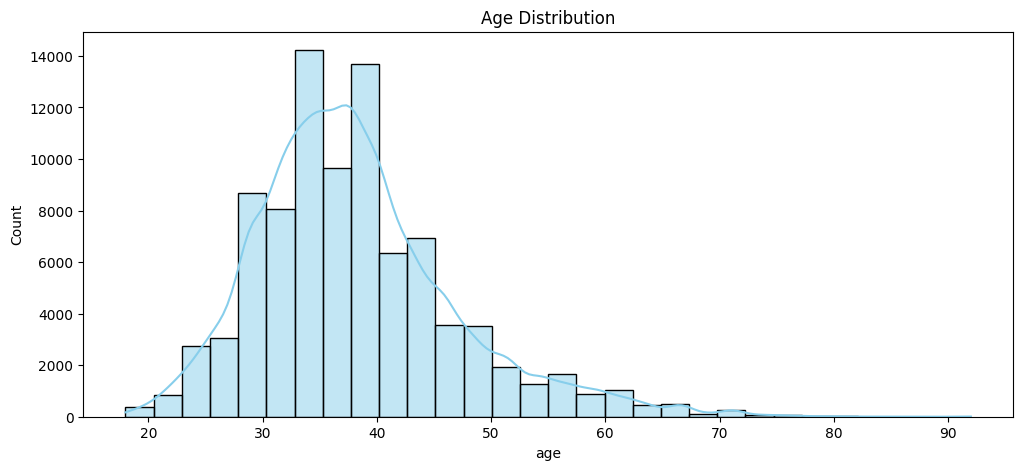

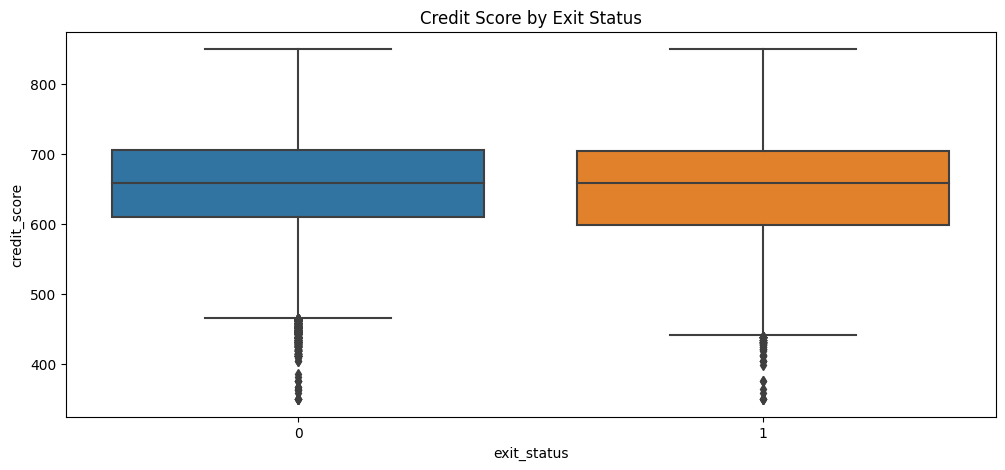

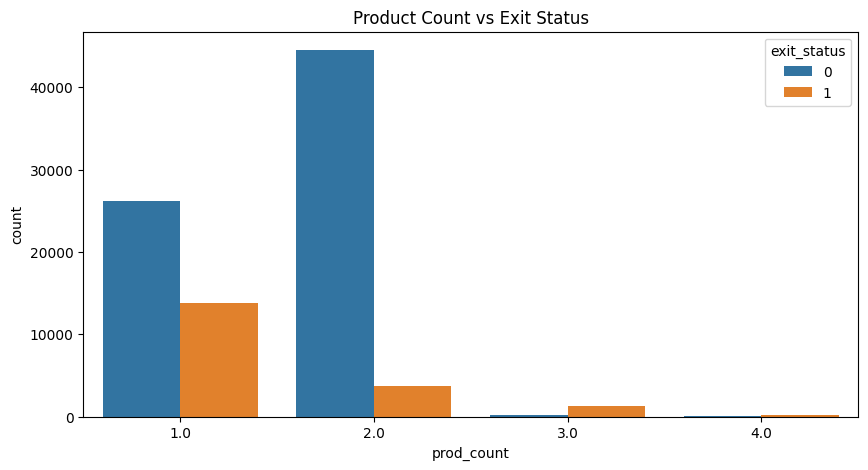

In [9]:

plt.figure(figsize=(12, 5))
sns.histplot(train['age'], bins=30, kde=True, color='skyblue')
plt.title("Age Distribution")
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(x='exit_status', y='credit_score', data=train)
plt.title("Credit Score by Exit Status")
plt.show()

plt.figure(figsize=(10, 5))
sns.countplot(x='prod_count', hue='exit_status', data=train)
plt.title("Product Count vs Exit Status")
plt.show()


## Encode Categorical

In [10]:

le = LabelEncoder()
train['gender'] = le.fit_transform(train['gender'])
test['gender'] = le.transform(test['gender'])

# One-hot encode 'country'
train = pd.get_dummies(train, columns=['country'], drop_first=True)
test = pd.get_dummies(test, columns=['country'], drop_first=True)

# Align test and train columns
test = test.reindex(columns=train.columns.drop('exit_status'), fill_value=0)


## Outlier detection

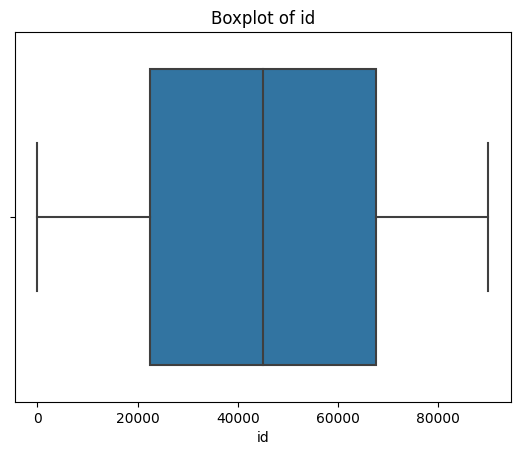

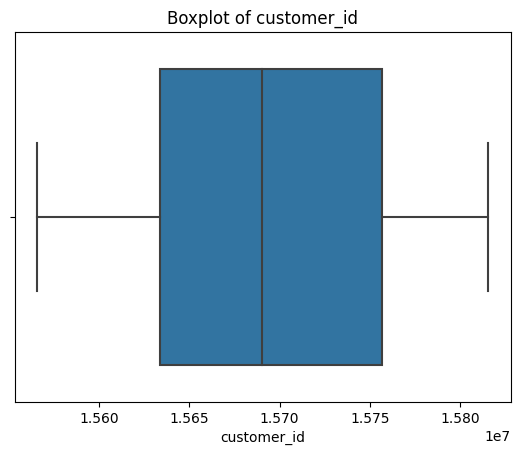

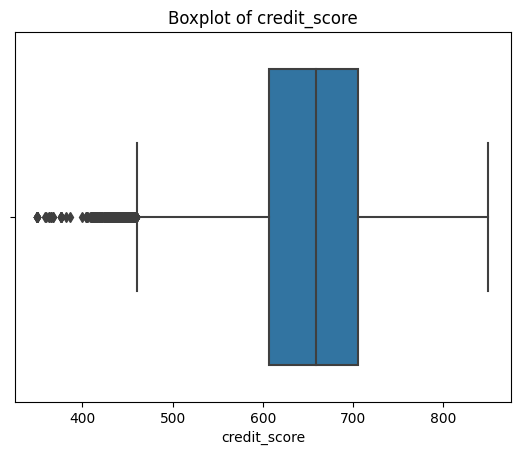

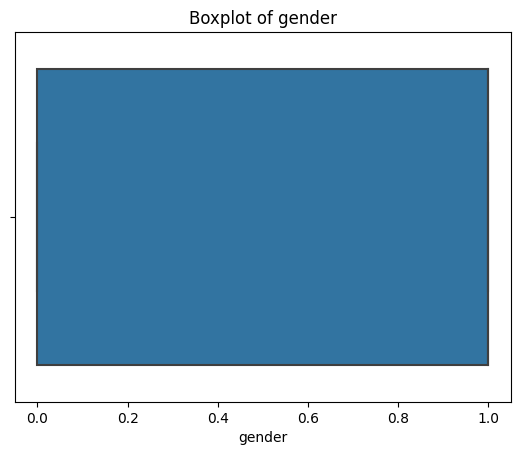

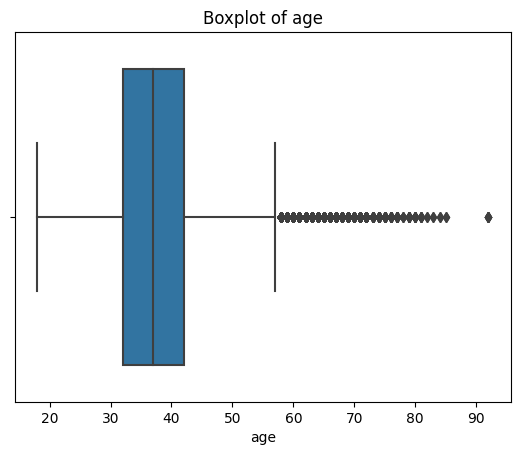

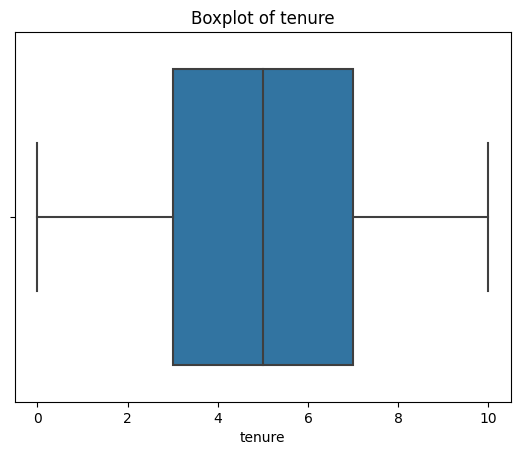

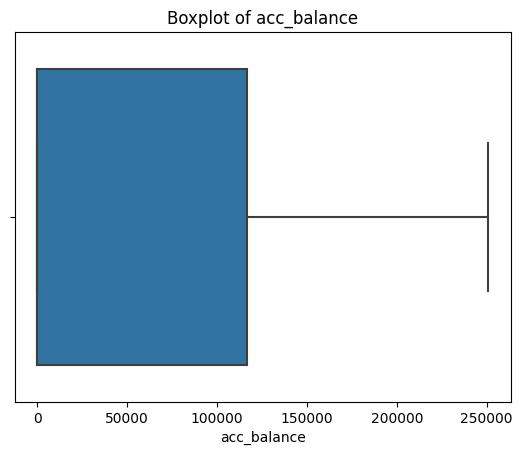

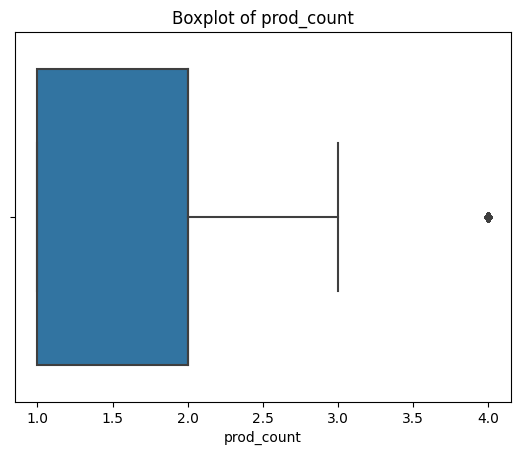

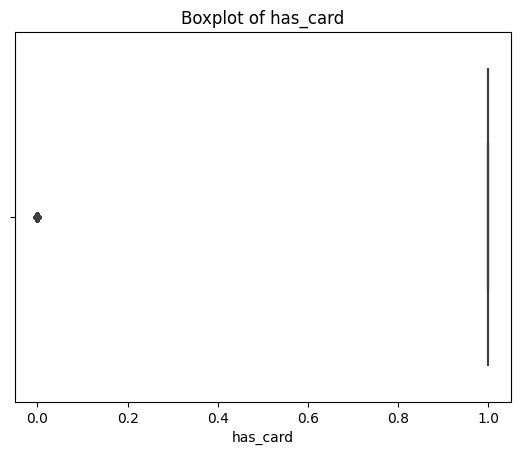

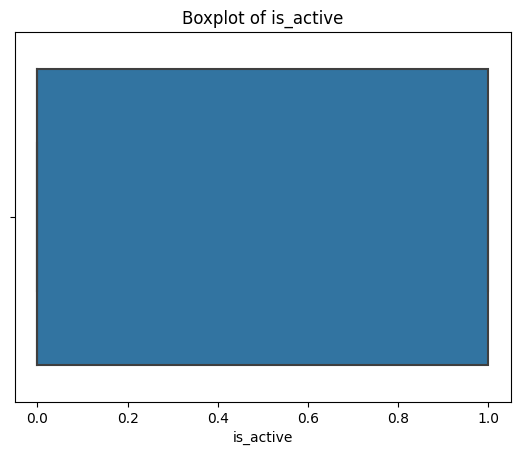

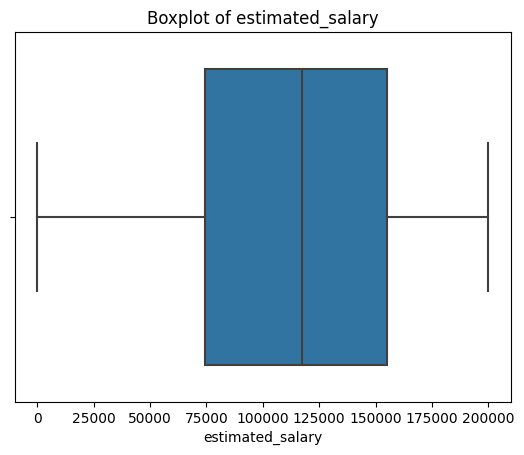

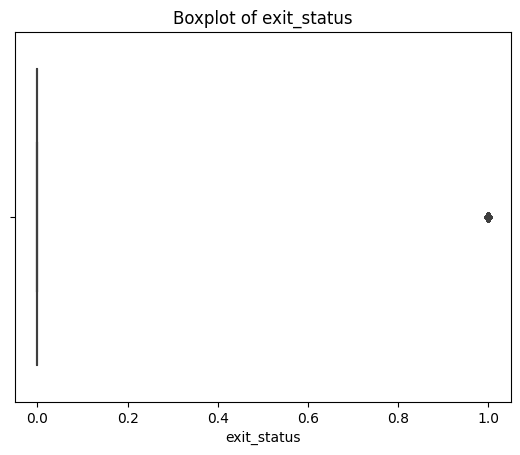

In [11]:
numerical_cols = train.select_dtypes(include=np.number).columns
for col in numerical_cols:
    sns.boxplot(data=train, x=col)
    plt.title(f"Boxplot of {col}")
    plt.show()

## Outlier Handling - Clip

In [12]:

for col in ['credit_score', 'age']:
    q1 = train[col].quantile(0.01)
    q99 = train[col].quantile(0.99)
    train[col] = train[col].clip(q1, q99)
    test[col] = test[col].clip(q1, q99)


## Feature Scaling

In [13]:

scale_cols = ['credit_score', 'age', 'acc_balance', 'estimated_salary']
scaler = StandardScaler()
train[scale_cols] = scaler.fit_transform(train[scale_cols])
test[scale_cols] = scaler.transform(test[scale_cols])


## Train-Test Split

In [ ]:

X = train.drop(columns=['exit_status', 'id', 'customer_id', 'last_name'])
y = train['exit_status']
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


## Model Evaluation

In [15]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVC": SVC(probability=True),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Bagging": BaggingClassifier(),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

print("\nModel Evaluation on Validation Set:")
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    acc = accuracy_score(y_val, preds)
    print(f"\n{name} Accuracy: {acc:.4f}")
    print(classification_report(y_val, preds, zero_division=0))



Model Evaluation on Validation Set:

Logistic Regression Accuracy: 0.8311
              precision    recall  f1-score   support

           0       0.85      0.95      0.90     14209
           1       0.68      0.37      0.48      3791

    accuracy                           0.83     18000
   macro avg       0.77      0.66      0.69     18000
weighted avg       0.81      0.83      0.81     18000


Random Forest Accuracy: 0.8546
              precision    recall  f1-score   support

           0       0.88      0.95      0.91     14209
           1       0.72      0.51      0.60      3791

    accuracy                           0.85     18000
   macro avg       0.80      0.73      0.75     18000
weighted avg       0.84      0.85      0.85     18000


KNN Accuracy: 0.8361
              precision    recall  f1-score   support

           0       0.87      0.94      0.90     14209
           1       0.66      0.46      0.54      3791

    accuracy                           0.84     18000

## Richer Evaluation: F1, ROC-AUC, Confusion Matrix

Accuracy alone is misleading on imbalanced classification (churn typically has 15-25% positives). The cells below report F1, ROC-AUC and the confusion matrix on the validation set, plus stratified 5-fold cross-validated F1 for each candidate model.

In [ ]:
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
summary = []
for name, model in models.items():
    val_pred = model.predict(X_val)
    val_proba = (
        model.predict_proba(X_val)[:, 1]
        if hasattr(model, 'predict_proba') else None
    )
    cv_f1 = cross_val_score(model, X_train, y_train,
                            cv=cv, scoring='f1', n_jobs=-1).mean()
    summary.append({
        'model': name,
        'val_acc': accuracy_score(y_val, val_pred),
        'val_f1': f1_score(y_val, val_pred),
        'val_auc': roc_auc_score(y_val, val_proba) if val_proba is not None else None,
        'cv_f1_mean': cv_f1,
    })
summary_df = pd.DataFrame(summary).sort_values('cv_f1_mean', ascending=False)
print(summary_df.to_string(index=False))

best_name = summary_df.iloc[0]['model']
print('\nConfusion matrix for best model:', best_name)
print(confusion_matrix(y_val, models[best_name].predict(X_val)))


## Hyperparameter Tuning

In [ ]:
print("\n\n🔍 Hyperparameter Tuning")

# Logistic Regression
param_lr = {'C': [0.01, 0.1, 1]}
gs_lr = GridSearchCV(LogisticRegression(max_iter=1000), param_lr, cv=3)
gs_lr.fit(X_train, y_train)
print("Best Logistic Regression:", gs_lr.best_params_)

# Random Forest
param_rf = {'n_estimators': [50, 100], 'max_depth': [4, 6]}
gs_rf = GridSearchCV(RandomForestClassifier(), param_rf, cv=3)
gs_rf.fit(X_train, y_train)
print("Best Random Forest:", gs_rf.best_params_)

# KNN
param_knn = {'n_neighbors': [3, 5, 7]}
gs_knn = GridSearchCV(KNeighborsClassifier(), param_knn, cv=3)
gs_knn.fit(X_train, y_train)
print("Best KNN:", gs_knn.best_params_)

# Gradient Boosting
param_gb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1],
}
gs_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42), param_gb,
    cv=5, scoring='f1', n_jobs=-1,
)
gs_gb.fit(X_train, y_train)
print("Best Gradient Boosting:", gs_gb.best_params_, "F1:", round(gs_gb.best_score_, 4))

# XGBoost
param_xgb = {
    'n_estimators': [200, 400],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
}
gs_xgb = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42), param_xgb,
    cv=5, scoring='f1', n_jobs=-1,
)
gs_xgb.fit(X_train, y_train)
print("Best XGBoost:", gs_xgb.best_params_, "F1:", round(gs_xgb.best_score_, 4))


## Final Model & Submission

In [ ]:
# Use the tuned Gradient Boosting model (best params from GridSearchCV above)
final_model = gs_gb.best_estimator_
final_model.fit(X, y)

# Submission
final_test = test.drop(columns=['last_name'], errors='ignore')
final_preds = final_model.predict(
    final_test.drop(columns=['id', 'customer_id'], errors='ignore')
)
submission = pd.DataFrame({'id': test['id'], 'exit_status': final_preds})
submission.to_csv('submission.csv', index=False)
print('submission.csv created with', len(submission), 'rows')


In [18]:
submission.head()

,id,exit_status
0,0,0
1,1,1
2,2,0
3,3,0
4,4,0
